# Correlation and distance analysis between Gene expression and ATAC-seq data


After analyzing the ATAC-seq and RNA-seq datasets doing different clusters we want to see how gene expression and ATAC-seq regions correlate and analyze the distance between genes and CREs. This will give use important information to uncover regulatory programms from ILCs.

In this Notebook we are going to be solving the following questions:

2. iii Can one use correlation analysis and distance information to associate ATAC-seq regions with gene expression?

a) Where are associated CREs located with respect to the TSS?
b) Where are the most associated CREs located?
c) How many CREs are associated with genes?
d) Is every promoter associated with a gene?
e) Are some promoters associated with other genes?
f) What is the closest associated CRE to a gene?
g) Are there CREs that control several genes?

To do this, we are going to use different statistical methods such as Pearson correlation. The results are visualized in some cases using plots, histograms and heatmaps. 

1. Load the datasets, filtering, obtaining TSS per each gene and associating OCRs with near genes 

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [4]:
atac = pd.read_csv("data/ImmGenATAC18_AllOCRsInfo.csv")
rna = pd.read_csv("data/mmc2.csv")
refflat = pd.read_csv("data/refFlat.txt", sep="\t", header=None)
refflat.columns = [
    "geneName", "name2", "chrom", "strand", "txStart", "txEnd",
    "cdsStart", "cdsEnd", "exonCount", "exonStarts", "exonEnds"
]


In [5]:
cell_types = [
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
]


In [6]:
rna = rna.rename(columns={"Unnamed: 0": "gene"})
rna_filtered = rna.set_index("gene")[cell_types]

atac = atac[atac[cell_types].notnull().all(axis=1)].copy()
atac["midpoint"] = atac["Summit"]
atac_filtered = atac[["ImmGenATAC1219.peakID", "chrom", "midpoint", "genes.within.100Kb"] + cell_types]


In [7]:
refflat["TSS"] = np.where(refflat["strand"] == "+", refflat["txStart"], refflat["txEnd"])
gene_tss = refflat[["geneName", "chrom", "TSS"]].drop_duplicates()

The following code is used to find associations between OCRs and Genes without filtering for correlation. This means that negative correlations are also considered. CREs that correlate negatively with Genes are probably repressors. 

In [8]:
rows = []
window = 100_000

for i, row in atac_filtered.iterrows():
    peak_id = row["ImmGenATAC1219.peakID"]
    chrom = row["chrom"]
    midpoint = row["midpoint"]
    signal = row[cell_types].values
    if pd.isna(row["genes.within.100Kb"]):
        continue

    genes = [g.strip() for g in str(row["genes.within.100Kb"]).split(";")]
    for gene in genes:
        if gene in rna_filtered.index and gene_tss["geneName"].eq(gene).any():
            gene_row = gene_tss[gene_tss["geneName"] == gene]
            gene_chrom = gene_row["chrom"].values[0]
            tss = gene_row["TSS"].values[0]

            if gene_chrom != chrom:
                continue

            expr = rna_filtered.loc[gene].values
            corr, _ = pearsonr(signal, expr)

            rows.append({
                "ocr_id": peak_id,
                "gene": gene,
                "chrom": chrom,
                "distance": midpoint - tss,
                "abs_distance": abs(midpoint - tss),
                "correlation": corr
            })

all_assoc_df = pd.DataFrame(rows)
print("Associations OCR ↔ gen:", all_assoc_df.shape)

/var/folders/cy/bvr0t8gn719b64ym133x5y7m0000gn/T/ipykernel_1645/4101964422.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(signal, expr)


Associations OCR ↔ gen: (98593, 6)


In [10]:
pip install pandas matplotlib intervaltree

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'intervaltree' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'intervaltree'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26191 sha256=54fffef213be22f64f9213a64b9ef605421c027c780b8d83802b21ebb2046d4d
  Stored in directory: /Users/paulagutierrezposse/Library/Caches/pip/wheels/ab/fa/1b/75d9a713279796785711bd0bad8334aaace560c0bd28830c8c
Successfully built intervaltree
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [intervaltree]
Note: you may need to restart the kernel to use updated packages.


['ImmGenATAC1219.peakID', 'chrom', 'Summit', 'mm10.60way.phastCons_scores', '_-log10_bestPvalue', 'Included.in.systematic.analysis', 'TSS', 'genes.within.100Kb', 'LTHSC.34-.BM', 'LTHSC.34+.BM', 'STHSC.150-.BM', 'MPP4.135+.BM', 'proB.CLP.BM', 'proB.FrA.BM', 'proB.FrBC.BM', 'preB.FrD.BM', 'B.FrE.BM', 'B1b.PC', 'B.T1.Sp', 'B.T2.Sp', 'B.T3.Sp', 'B.Sp', 'B.Fem.Sp', 'B.MZ.Sp', 'B.Fo.Sp', 'B.mem.Sp', 'B.GC.CB.Sp', 'B.GC.CC.Sp', 'B.PB.Sp', 'B.PC.Sp', 'B.PC.BM', 'preT.DN1.Th', 'preT.DN2a.Th', 'preT.DN2b.Th', 'preT.DN3.Th', 'T.DN4.Th', 'T.ISP.Th', 'T.DP.Th', 'T.4.Th', 'T.8.Th', 'T.4.Nve.Sp', 'T.4.Nve.Fem.Sp', 'T.8.Nve.Sp', 'T.4.Sp.aCD3+CD40.18hr', 'Treg.4.FP3+.Nrplo.Co', 'Treg.4.25hi.Sp', 'T8.TN.P14.Sp', 'T8.IEL.LCMV.d7.SI', 'T8.TE.LCMV.d7.Sp', 'T8.MP.LCMV.d7.Sp', 'T8.Tcm.LCMV.d180.Sp', 'T8.Tem.LCMV.d180.Sp', 'NKT.Sp', 'NKT.Sp.LPS.3hr', 'NKT.Sp.LPS.18hr', 'NKT.Sp.LPS.3d', 'Tgd.g2+d17.24a+.Th', 'Tgd.g2+d17.LN', 'Tgd.g2+d1.24a+.Th', 'Tgd.g2+d1.LN', 'Tgd.g1.1+d1.24a+.Th', 'Tgd.g1.1+d1.LN', 'Tgd.Sp'

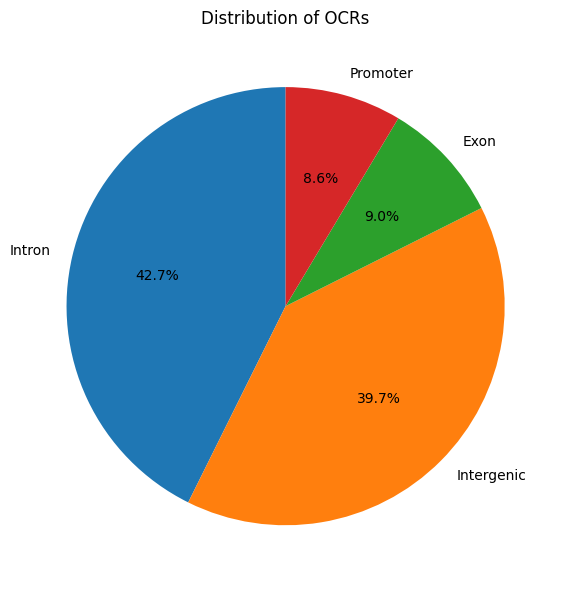

In [25]:
import pandas as pd
from intervaltree import IntervalTree
import matplotlib.pyplot as plt
from collections import defaultdict

ocr_df = pd.read_csv("./data/ImmGenATAC18_AllOCRsInfo.csv")
print(ocr_df.columns.tolist())
refFlat = pd.read_csv("./data/refFlat.txt", sep="\t", header=None)

refFlat.columns = [
    "geneName", "name", "chrom", "strand", "txStart", "txEnd",
    "cdsStart", "cdsEnd", "exonCount", "exonStarts", "exonEnds"
]

promoters, exons, genes = defaultdict(IntervalTree), defaultdict(IntervalTree), defaultdict(IntervalTree)

for _, row in refFlat.iterrows():
    chrom = row["chrom"]
    strand = row["strand"]
    tx_start, tx_end = row["txStart"], row["txEnd"]
    tss = tx_start if strand == "+" else tx_end

    p_start = tss - 1000 if strand == "+" else tss - 100
    p_end   = tss + 100  if strand == "+" else tss + 1000
    promoters[chrom].addi(p_start, p_end)

    genes[chrom].addi(tx_start, tx_end)

    exon_starts = list(map(int, row["exonStarts"].strip(",").split(",")))
    exon_ends = list(map(int, row["exonEnds"].strip(",").split(",")))
    for start, end in zip(exon_starts, exon_ends):
        exons[chrom].addi(start, end)

def classify_ocr(row):
    chrom, start, end = row["chr"], row["start"], row["end"]
    if chrom not in promoters:
        return "Intergenic"
    if promoters[chrom].overlaps(start, end):
        return "Promoter"
    elif exons[chrom].overlaps(start, end):
        return "Exon"
    elif genes[chrom].overlaps(start, end):
        return "Intron"
    else:
        return "Intergenic"

ocr_df = ocr_df.rename(columns={"chrom": "chr"})
ocr_df["start"] = ocr_df["Summit"] - 250
ocr_df["end"] = ocr_df["Summit"] + 250
ocr_df = ocr_df.rename(columns=lambda x: x.lower())

ocr_df["annotation"] = ocr_df.apply(classify_ocr, axis=1)

counts = ocr_df["annotation"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
counts.plot(kind="pie", autopct="%.1f%%", startangle=90, ylabel="")
plt.title("Distribution of OCRs")
plt.tight_layout()
plt.savefig("Distribution_of_OCRs.png", dpi=300)
plt.show()




# Enhancers and Promoters

This code also finds associations between OCRs and Genes but filters for only positive correlations. This means that all associated CREs that are found have to be enhancers or promoters. For this part of the analysis we are going to use this code to find promoters or enhancers.

In [23]:
from scipy.stats import pearsonr
import pandas as pd

rows = []
window = 100_000

for i, row in atac_filtered.iterrows():
    peak_id = row["ImmGenATAC1219.peakID"]
    chrom = row["chrom"]
    midpoint = row["midpoint"]
    signal = row[cell_types].values

    if pd.isna(row["genes.within.100Kb"]):
        continue

    genes = [g.strip() for g in str(row["genes.within.100Kb"]).split(";")]
    for gene in genes:
        if gene in rna_filtered.index and gene_tss["geneName"].eq(gene).any():
            gene_row = gene_tss[gene_tss["geneName"] == gene]
            gene_chrom = gene_row["chrom"].values[0]
            tss = gene_row["TSS"].values[0]

            if gene_chrom != chrom:
                continue

            expr = rna_filtered.loc[gene].values
            corr, _ = pearsonr(signal, expr)

            if corr > 0: 
                rows.append({
                    "ocr_id": peak_id,
                    "gene": gene,
                    "chrom": chrom,
                    "distance": midpoint - tss,
                    "abs_distance": abs(midpoint - tss),
                    "correlation": corr
                })

assoc_df = pd.DataFrame(rows)

print("Associations OCR ↔ gen (correlation > 0):", assoc_df.shape)
print("Average Correlation:", assoc_df["correlation"].mean())

/var/folders/cy/bvr0t8gn719b64ym133x5y7m0000gn/T/ipykernel_1645/1215522302.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(signal, expr)


Associations OCR ↔ gen (correlation > 0): (49990, 6)
Average Correlation: 0.3662783731220586


2. Calculating average correlation to see if it is viable to use it for further analysis. The average correlation is 0.37. This means that Gene expression correlates very well with Chromatin Accesibility and can be used to find CREs.

In [41]:
print("Average Correlation:", assoc_df["correlation"].mean())

Average Correlation: 0.3662783731220586


3. Answering question a). We can determine from the plot that CREs are located mostly on TSSs or very close to them.

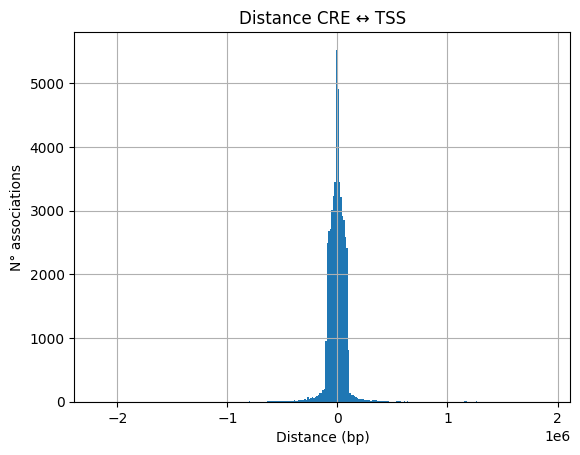

In [42]:
plt.figure()
assoc_df["distance"].hist(bins=300)
plt.title("Distance CRE ↔ TSS")
plt.xlabel("Distance (bp)")
plt.ylabel("N° associations")
plt.savefig("Distance_CRE-TSS.png", dpi=300, bbox_inches="tight")
plt.show()


4. Answering question b). The following table shows how far away are the most associated CREs to each gene located.

TOP 10 more associated CREs:
                            ocr_id           gene  chrom  distance  \
20196  ImmGenATAC1219.peak_203677           Ets2  chr16     46963   
10306  ImmGenATAC1219.peak_108346  9430078K24Rik  chr12    -67017   
42191  ImmGenATAC1219.peak_428162           Nav2   chr7    292471   
37453  ImmGenATAC1219.peak_375291         Ptpn13   chr5     72435   
15663  ImmGenATAC1219.peak_161017           Klf5  chr14      9258   
...                           ...            ...    ...       ...   
261      ImmGenATAC1219.peak_1328         Gm5523   chr1     23118   
12079  ImmGenATAC1219.peak_125344           Nrn1  chr13     24554   
17131  ImmGenATAC1219.peak_170309          Rrm2b  chr15    -27525   
34888  ImmGenATAC1219.peak_344000          Glis1   chr4     49548   
26078  ImmGenATAC1219.peak_260326           Rsu1   chr2    -66648   

       abs_distance  correlation  
20196         46963     0.999173  
10306         67017     0.999055  
42191        292471     0.998503  
3

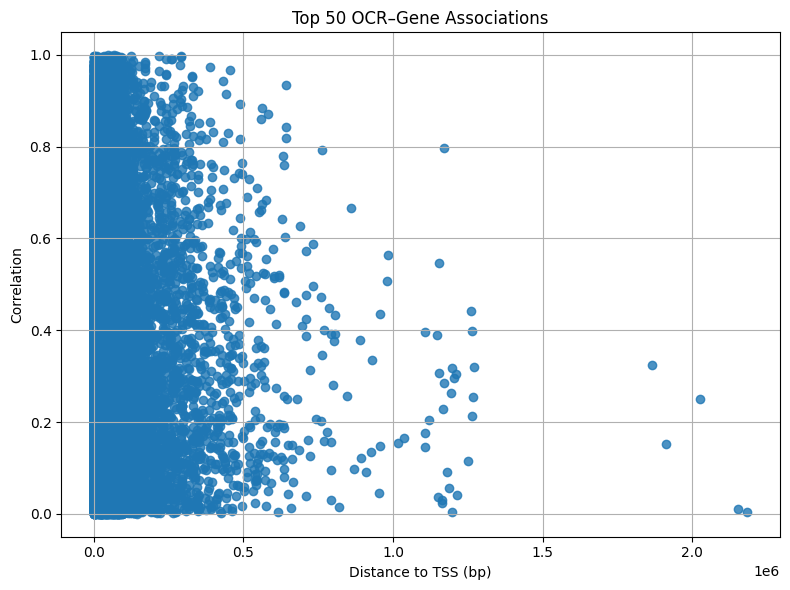

In [35]:
top_assoc = assoc_df.sort_values(by="correlation", ascending=False)
print("TOP 10 more associated CREs:\n", top_assoc)

plt.figure(figsize=(8, 6))
plt.scatter(top_assoc["abs_distance"], top_assoc["correlation"], alpha=0.8)
plt.xlabel("Distance to TSS (bp)")
plt.ylabel("Correlation")
plt.title("Top 50 OCR–Gene Associations")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

print(ocr_df[["immgenatac1219.peakid", "annotation"]].head())

   immgenatac1219.peakid  annotation
0  ImmGenATAC1219.peak_1  Intergenic
1  ImmGenATAC1219.peak_2  Intergenic
2  ImmGenATAC1219.peak_3  Intergenic
3  ImmGenATAC1219.peak_4  Intergenic
4  ImmGenATAC1219.peak_5      Intron


In [29]:
ocr_df = ocr_df.rename(columns={"immgenatac1219.peakid": "ocr_id"})

In [30]:
assoc_annotated = assoc_df.merge(ocr_df[["ocr_id", "annotation"]], on="ocr_id", how="left")

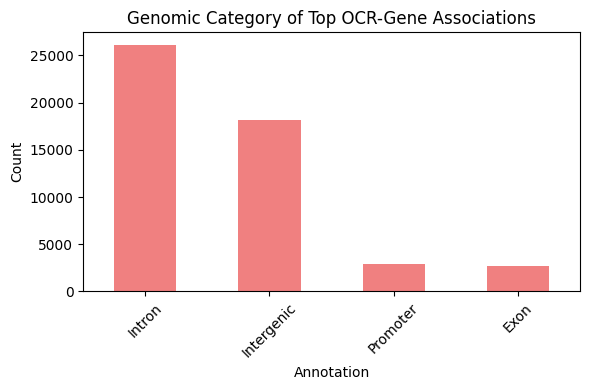

In [36]:
top_assoc = assoc_annotated.sort_values(by="correlation", ascending=False)

plt.figure(figsize=(6, 4))
top_assoc["annotation"].value_counts().plot(kind="bar", color="lightcoral")
plt.title("Genomic Category of Top OCR-Gene Associations")
plt.ylabel("Count")
plt.xlabel("Annotation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Genomic_Category_of_Top_OCR-Gene_Associations.png", dpi=300)
plt.show()

5. Answering question c). There are 98593 OCRs associated to genes, from those 49990 have a positive correlation. 

In [44]:
print("CREs associated to genes:", assoc_df["ocr_id"].nunique())

CREs associated to genes: 49990


6. Answering question d) and e). There are 1489 genes with CREs on their promoters, a small number when compared to the total numbers of CREs associated to genes, which means that the majority of CREs are enhancers. There are no promoters associated with more than 1 gene.

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

atac_path = "data/ImmGenATAC18_AllOCRsInfo.csv"
rna_path = "data/mmc2.csv"
refFlat_path = "data/refFlat.txt"

atac = pd.read_csv(atac_path)
atac["midpoint"] = atac["Summit"]

cell_types = [
    "NK.27+11b-.BM", "NK.27+11b+.BM", "NK.27-11b+.BM",
    "NK.27+11b-.Sp", "NK.27+11b+.Sp", "NK.27-11b+.Sp",
    "ILC2.SI", "ILC3.NKp46-CCR6-.SI", "ILC3.NKp46+.SI", "ILC3.CCR6+.SI"
]
atac_filtered = atac[["ImmGenATAC1219.peakID", "chrom", "midpoint", "genes.within.100Kb"] + cell_types].dropna()

rna = pd.read_csv(rna_path)
rna.columns.values[0] = "gene"
rna.set_index("gene", inplace=True)
rna_filtered = rna[cell_types].dropna()

refFlat = pd.read_csv(refFlat_path, sep="\t", header=None, names=[
    "geneName", "transcript", "chrom", "strand", "txStart", "txEnd",
    "cdsStart", "cdsEnd", "exonCount", "exonStarts", "exonEnds"
])
refFlat = refFlat[refFlat["chrom"].str.startswith("chr")]
refFlat["TSS"] = np.where(refFlat["strand"] == "+", refFlat["txStart"], refFlat["txEnd"])
gene_tss = refFlat.groupby("geneName")[["chrom", "TSS"]].first().reset_index()

In [18]:
rows = []
for i, row in atac_filtered.iterrows():
    peak_id = row["ImmGenATAC1219.peakID"]
    chrom = row["chrom"]
    midpoint = row["midpoint"]
    signal = row[cell_types].values
    genes = str(row["genes.within.100Kb"]).split(";")

    for gene in genes:
        gene = gene.strip()
        if gene in rna_filtered.index and gene_tss["geneName"].eq(gene).any():
            gene_row = gene_tss[gene_tss["geneName"] == gene]
            gene_chrom = gene_row["chrom"].values[0]
            tss = gene_row["TSS"].values[0]
            if gene_chrom != chrom:
                continue
            expr = rna_filtered.loc[gene].values
            corr, _ = pearsonr(signal, expr)

            rows.append({
                "ocr_id": peak_id,
                "gene": gene,
                "chrom": chrom,
                "distance": midpoint - tss,
                "abs_distance": abs(midpoint - tss),
                "correlation": corr
            })

assoc_df = pd.DataFrame(rows)
assoc_df.to_csv("assoc_df.csv", index=False) 

/var/folders/cy/bvr0t8gn719b64ym133x5y7m0000gn/T/ipykernel_6233/1939566184.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(signal, expr)


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

promoter_assoc = assoc_df[assoc_df["abs_distance"] <= 2000]
genes_with_promoter = promoter_assoc["gene"].nunique()
print("Genes with CREs in promoter:", genes_with_promoter)

multi_gene_promoters = promoter_assoc.groupby("ocr_id")["gene"].nunique()
multi_gene_promoters = multi_gene_promoters[multi_gene_promoters > 1]
print("Promoters associated to more than 1 gene:", multi_gene_promoters.shape[0])


Genes with CREs in promoter: 1489
Promoters associated to more than 1 gene: 0


7. Answering question f). On the table we are able to see 30 genes and its closest CRE in order to visualize the results.

In [46]:
closest = assoc_df.loc[assoc_df.groupby("gene")["abs_distance"].idxmin()]
print("closest CREs to each gene (first 30):\n", closest.head(30))

closest CREs to each gene (first 30):
                            ocr_id            gene  chrom  distance  \
8719    ImmGenATAC1219.peak_85693   0610039H22Rik  chr11     -4041   
36625  ImmGenATAC1219.peak_367961   0610040J01Rik   chr5       251   
31235  ImmGenATAC1219.peak_307975   1110032F04Rik   chr3       -33   
6185    ImmGenATAC1219.peak_55489   1500009L16Rik  chr10     31142   
20235  ImmGenATAC1219.peak_203764   1600002D24Rik  chr16    -56461   
20576  ImmGenATAC1219.peak_206470   1700010I14Rik  chr17       -53   
43231  ImmGenATAC1219.peak_439919   1700012D14Rik   chr7     63648   
33119  ImmGenATAC1219.peak_325847   1700012D16Rik   chr3      -229   
1057     ImmGenATAC1219.peak_7323   1700019D03Rik   chr1    -39418   
3001    ImmGenATAC1219.peak_25637   1700025G04Rik   chr1        44   
36705  ImmGenATAC1219.peak_368245   1700027F09Rik   chr5    -92826   
5593    ImmGenATAC1219.peak_46781   1700027J07Rik  chr10    -22770   
38340  ImmGenATAC1219.peak_389321   1700028E10Rik  

8. Answering question g). Yes there are many CREs that regulate more than one gene. This can be visualized in the histogram and the heatmap. This is an expected result according to biological literature. There are even genes such as Foxp1 that are associated with 383 genes.

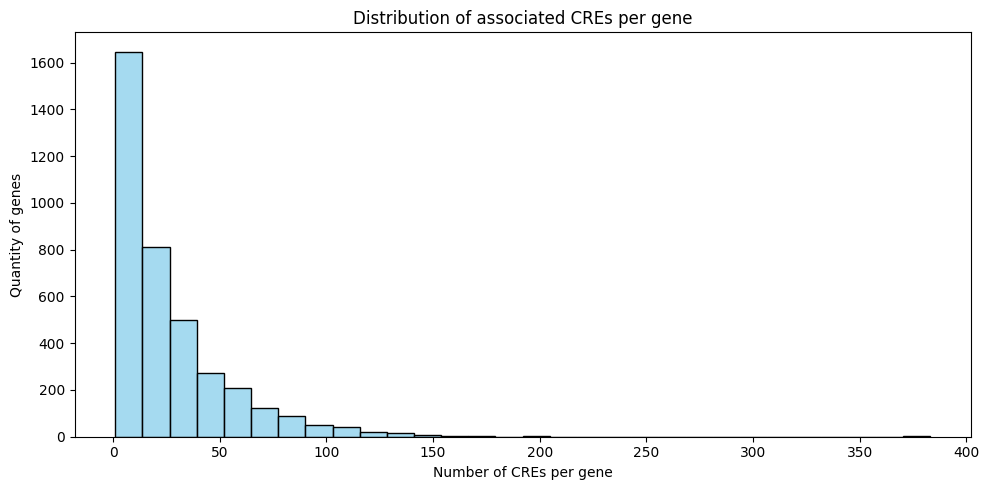

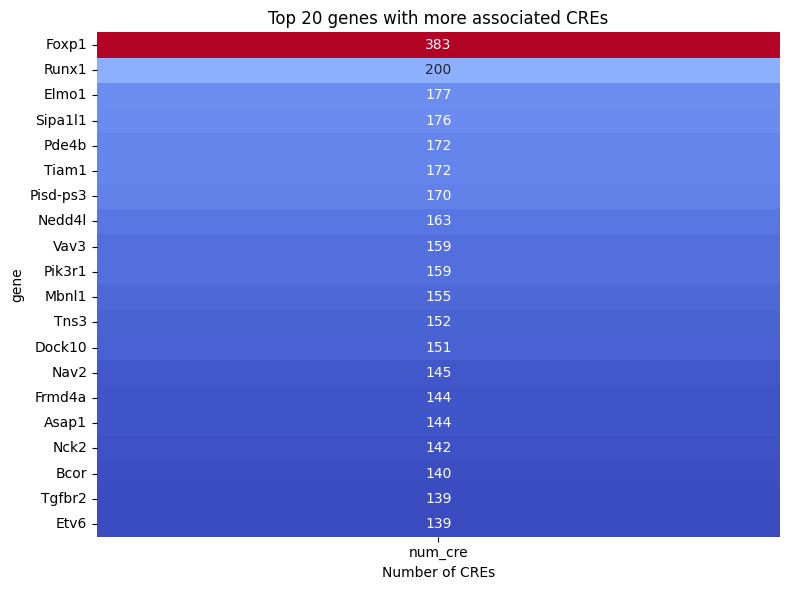

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assoc_df = pd.read_csv("assoc_df.csv")

cre_count_per_gene = assoc_df.groupby("gene")["ocr_id"].nunique().reset_index()
cre_count_per_gene.columns = ["gene", "num_cre"]

multi_cre_genes = cre_count_per_gene[cre_count_per_gene["num_cre"] > 1]

plt.figure(figsize=(10, 5))
sns.histplot(cre_count_per_gene["num_cre"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of associated CREs per gene")
plt.xlabel("Number of CREs per gene")
plt.ylabel("Quantity of genes")
plt.tight_layout()
plt.savefig("Distribution_associated_CREs_per_Gene.png", dpi=300)
plt.show()

top_genes = multi_cre_genes.sort_values("num_cre", ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.heatmap(top_genes.set_index("gene"), annot=True, fmt="d", cmap="coolwarm", cbar=False)
plt.title("Top 20 genes with more associated CREs")
plt.xlabel("Number of CREs")
plt.tight_layout()
plt.savefig("Genes_more_CREs.png", dpi=300)
plt.show()

9. Visualization of closest CRE to each gene with histograms, heatmaps and barplots

In [48]:
import pandas as pd

atac = pd.read_csv("data/ImmGenATAC18_AllOCRsInfo.csv")
refFlat = pd.read_csv("data/refFlat.txt", sep="\t", header=None)

refFlat.columns = ["geneName", "name", "chrom", "strand", "txStart", "txEnd", "cdsStart", "cdsEnd",
                   "exonCount", "exonStarts", "exonEnds"]

refFlat["TSS"] = refFlat.apply(lambda row: row["txStart"] if row["strand"] == "+" else row["txEnd"], axis=1)
gene_tss = refFlat.groupby("geneName")[["chrom", "TSS"]].first().reset_index()

atac = atac.rename(columns={"ImmGenATAC1219.peakID": "ocr_id"})
atac["midpoint"] = atac["Summit"].astype(int)

atac_sub = atac[["ocr_id", "chrom", "midpoint"]].copy()

closest = []
for _, row in gene_tss.iterrows():
    gene, chrom, tss = row["geneName"], row["chrom"], row["TSS"]
    nearby = atac_sub[(atac_sub["chrom"] == chrom) &
                      (abs(atac_sub["midpoint"] - tss) <= 100_000)].copy()
    if not nearby.empty:
        nearby["distance"] = abs(nearby["midpoint"] - tss)
        closest_ocr = nearby.loc[nearby["distance"].idxmin()]
        closest.append({
            "gene": gene,
            "ocr_id": closest_ocr["ocr_id"],
            "distance_to_tss": closest_ocr["distance"]
        })

closest_df = pd.DataFrame(closest)
closest_df.to_csv("closest_cre_per_gene.csv", index=False)
print(closest_df.head())

            gene                      ocr_id  distance_to_tss
0  0610005C13Rik  ImmGenATAC1219.peak_427235             1003
1  0610009B22Rik   ImmGenATAC1219.peak_75289              163
2  0610009E02Rik  ImmGenATAC1219.peak_263173               25
3  0610009L18Rik   ImmGenATAC1219.peak_95335               68
4  0610010F05Rik   ImmGenATAC1219.peak_70328               94


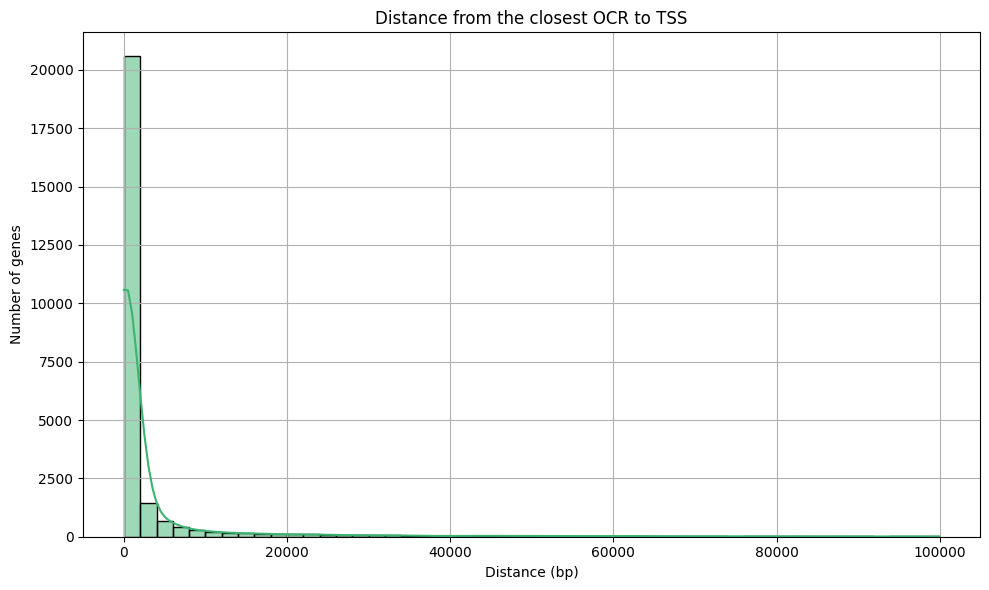

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("closest_cre_per_gene.csv")

plt.figure(figsize=(10, 6))
sns.histplot(df["distance_to_tss"], bins=50, kde=True, color='mediumseagreen')
plt.title("Distance from the closest OCR to TSS")
plt.xlabel("Distance (bp)")
plt.ylabel("Number of genes")
plt.grid(True)
plt.tight_layout()
plt.savefig("Distance_OCR_TSS.png", dpi=300)
plt.show()

Most of the genes have their closest OCR near the TSS, which was expected because all genes have promoters. The situations where the closest OCR is more than 2kb away from the TSS can also be realistic because not all promoters were available by the time of the experiment. 

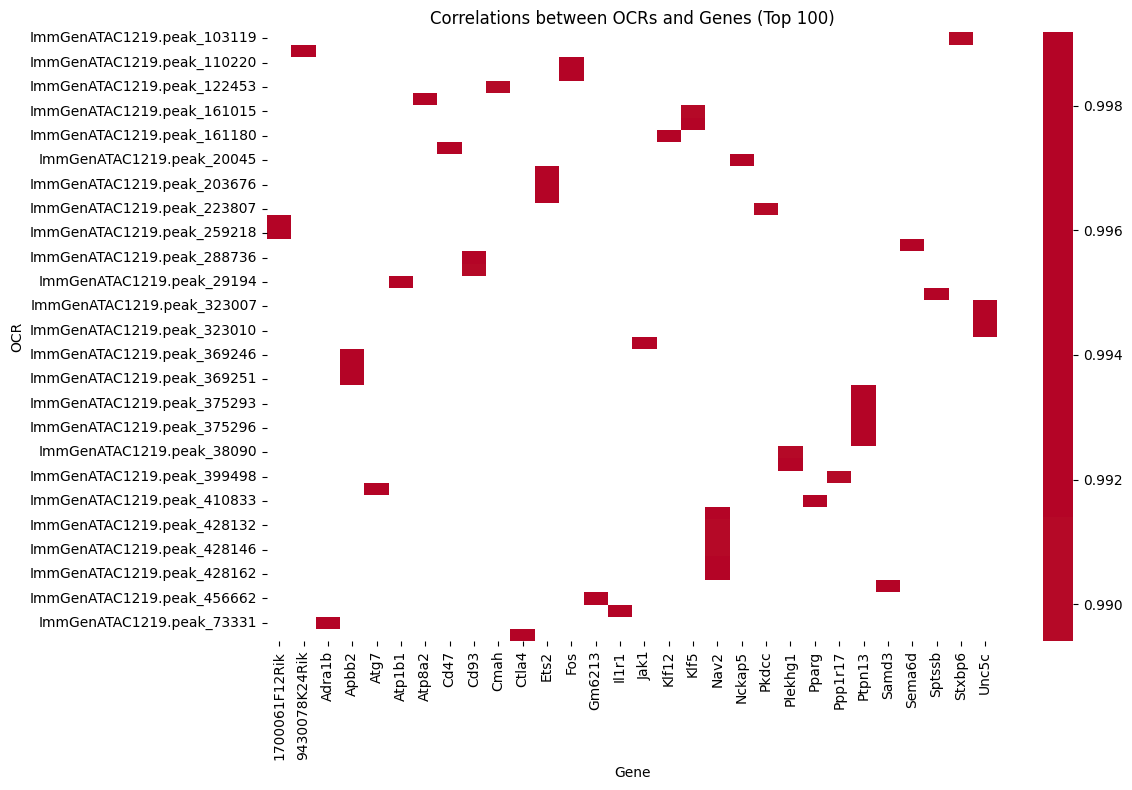

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

top_assoc = assoc_df.sort_values("correlation", ascending=False).head(50)

pivot = top_assoc.pivot(index="ocr_id", columns="gene", values="correlation")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="coolwarm", center=0)
plt.title("Correlations between OCRs and Genes (Top 100)")
plt.xlabel("Gene")
plt.ylabel("OCR")
plt.tight_layout()
plt.savefig("Correlation_OCR_Gene.png", dpi=300)
plt.show()

This heatmap portrays the highest correlations between OCRs and genes. As seen, many of the OCRs correlate with more than one gene. Also some genes correlate with more than one OCR, which makes sense because genes have both promoters and enhancers. 

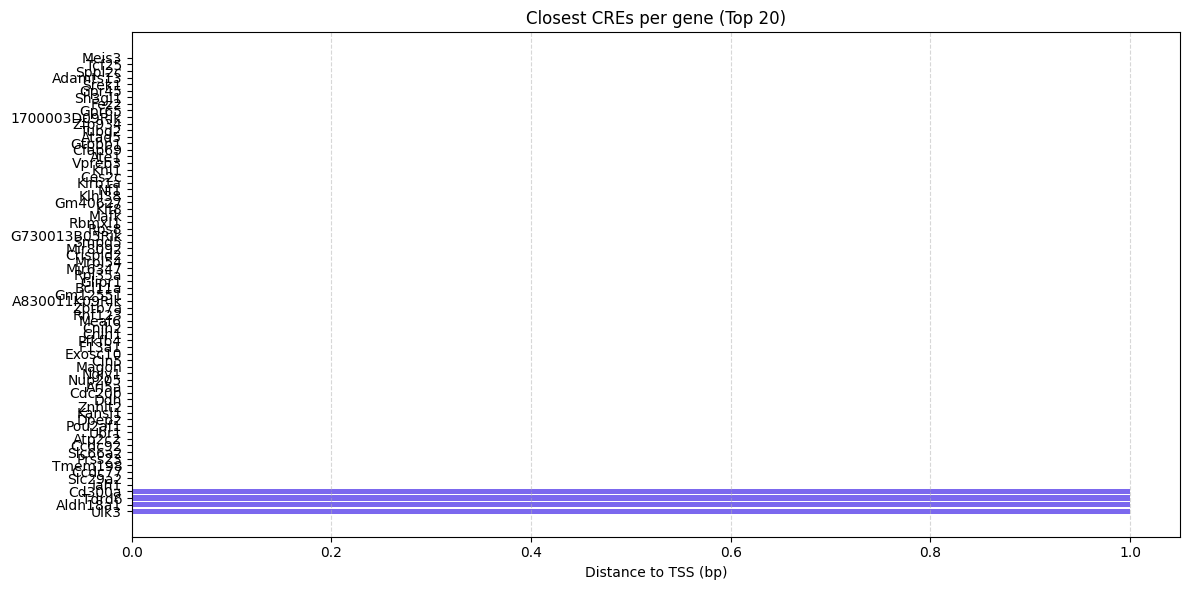

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("closest_cre_per_gene.csv", nrows=None) 

df['distance_to_tss'] = pd.to_numeric(df['distance_to_tss'], errors='coerce')

df = df.dropna(subset=['distance_to_tss'])

df_top = df.sort_values("distance_to_tss", key=abs).head(70)

plt.figure(figsize=(12, 6))
plt.barh(df_top['gene'], df_top['distance_to_tss'], color="mediumslateblue")
plt.xlabel("Distance to TSS (bp)")
plt.title("Closest CREs per gene (Top 20)")
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Closest_CREs.png", dpi=300)
plt.show()

This Grafic proves again that most of the closest CREs per gene are promoters and are therefore located in very close proximity to the gene

# Repressors

Next we are going to filter for negative correlations to analyze repressors. 

In [40]:
from scipy.stats import pearsonr
import pandas as pd

rows = []
window = 100_000

for i, row in atac_filtered.iterrows():
    peak_id = row["ImmGenATAC1219.peakID"]
    chrom = row["chrom"]
    midpoint = row["midpoint"]
    signal = row[cell_types].values

    if pd.isna(row["genes.within.100Kb"]):
        continue

    genes = [g.strip() for g in str(row["genes.within.100Kb"]).split(";")]
    for gene in genes:
        if gene in rna_filtered.index and gene_tss["geneName"].eq(gene).any():
            gene_row = gene_tss[gene_tss["geneName"] == gene]
            gene_chrom = gene_row["chrom"].values[0]
            tss = gene_row["TSS"].values[0]

            if gene_chrom != chrom:
                continue

            expr = rna_filtered.loc[gene].values
            corr, _ = pearsonr(signal, expr)

            if corr < 0: 
                rows.append({
                    "ocr_id": peak_id,
                    "gene": gene,
                    "chrom": chrom,
                    "distance": midpoint - tss,
                    "abs_distance": abs(midpoint - tss),
                    "correlation": corr
                })

repr_assoc_df = pd.DataFrame(rows)

print("Associations OCR ↔ gen (correlation < 0):", repr_assoc_df.shape)
print("Average Correlation:", repr_assoc_df["correlation"].mean())

/var/folders/cy/bvr0t8gn719b64ym133x5y7m0000gn/T/ipykernel_1645/2445974839.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(signal, expr)


Associations OCR ↔ gen (correlation < 0): (48602, 6)
Average Correlation: -0.2887264720987593


The only CREs with negative correlation are repressors, which can be located hundreds of kb away from tne TSS as proved by the plot comparing Distance between CRE and TSS.

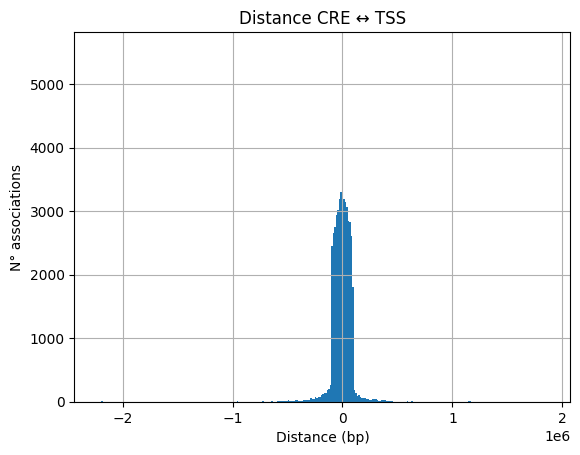

In [9]:
plt.figure()
repr_assoc_df["distance"].hist(bins=300)
plt.title("Distance CRE ↔ TSS")
plt.xlabel("Distance (bp)")
plt.ylabel("N° associations")
plt.savefig("Distance_CRE-TSS.png", dpi=300, bbox_inches="tight")
plt.show()

The following table shows the top 10 more associated repressors and where they are located.

In [ ]:

repressors = repr_assoc_df

top_repressors = repressors.sort_values("correlation").head(10)

print(top_repressors)

                           ocr_id     gene  chrom  distance  abs_distance  \
6641    ImmGenATAC1219.peak_59286     Btg1  chr10    -17254         17254   
28307  ImmGenATAC1219.peak_284079  Bcl2l11   chr2      2047          2047   
48454  ImmGenATAC1219.peak_511175  Sh3kbp1   chrX    -84371         84371   
16714  ImmGenATAC1219.peak_168330     Trio  chr15    -72541         72541   
3295    ImmGenATAC1219.peak_28453     Fasl   chr1    -83107         83107   
6642    ImmGenATAC1219.peak_59287     Btg1  chr10    -16997         16997   
21041  ImmGenATAC1219.peak_217062    Rftn1  chr17    -51326         51326   
2366    ImmGenATAC1219.peak_20139    Mgat5   chr1     23327         23327   
40055  ImmGenATAC1219.peak_410511     Atg7   chr6     28304         28304   
29029  ImmGenATAC1219.peak_294881    Ptpn1   chr2    -37098         37098   

       correlation  
6641     -0.988247  
28307    -0.982434  
48454    -0.981122  
16714    -0.977963  
3295     -0.966194  
6642     -0.964129  
21041

There are 48602 CREs that are negatively associated to genes, meaning they act as repressors. 

In [13]:
print("CREs negatively associated to genes:", repr_assoc_df["ocr_id"].nunique())

CREs negatively associated to genes: 48602


Now we made a table portraying the 30 of the closest Repressor to each gene

In [14]:
closest = repr_assoc_df.loc[repr_assoc_df.groupby("gene")["abs_distance"].idxmin()]
print("closest Repressor to each gene (first 30):\n", closest.head(30))

closest Repressor to each gene (first 30):
                            ocr_id            gene  chrom  distance  \
8837    ImmGenATAC1219.peak_85692   0610039H22Rik  chr11     -4378   
35785  ImmGenATAC1219.peak_367960   0610040J01Rik   chr5       -18   
30579  ImmGenATAC1219.peak_307976   1110032F04Rik   chr3       410   
6114    ImmGenATAC1219.peak_55487   1500009L16Rik  chr10     27517   
20275  ImmGenATAC1219.peak_203766   1600002D24Rik  chr16    -41186   
20566  ImmGenATAC1219.peak_206469   1700010I14Rik  chr17     -1483   
42240  ImmGenATAC1219.peak_439918   1700012D14Rik   chr7     61999   
32414  ImmGenATAC1219.peak_325846   1700012D16Rik   chr3      -607   
943      ImmGenATAC1219.peak_7328   1700019D03Rik   chr1    -32299   
2935    ImmGenATAC1219.peak_25632   1700025G04Rik   chr1     -5194   
35847  ImmGenATAC1219.peak_368249   1700027F09Rik   chr5    -90975   
5501    ImmGenATAC1219.peak_46782   1700027J07Rik  chr10    -22378   
37665  ImmGenATAC1219.peak_389320   1700028E10

Next we wanted to see if more than 1 repressor were associated with the same gene. We solved this by visualizing  plot that shows that there are many more genes with a small amount of associated Repressors. But some genes auch as Foxp1 associated with 157 Repressors. 

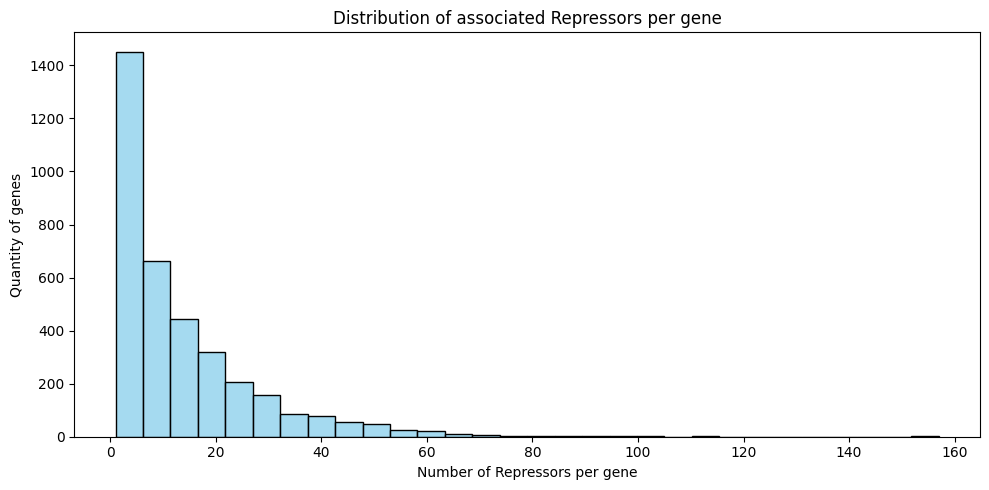

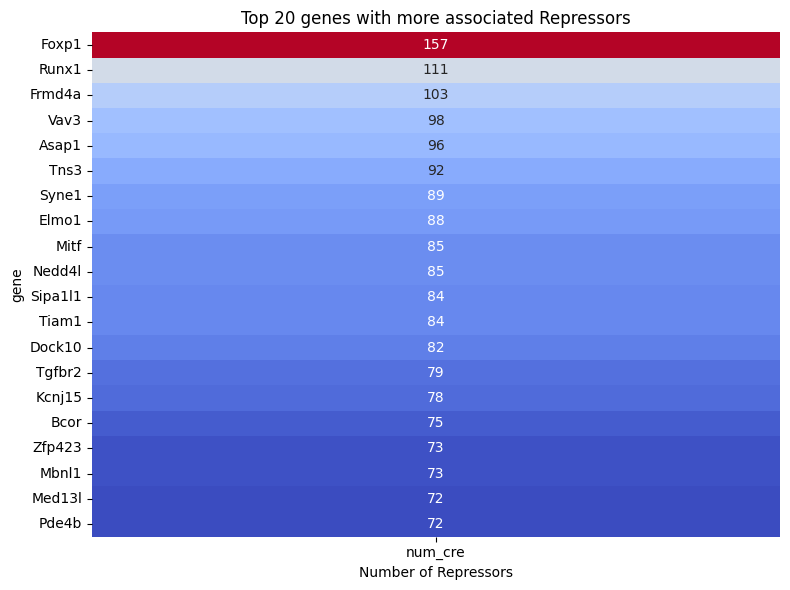

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cre_count_per_gene = repr_assoc_df.groupby("gene")["ocr_id"].nunique().reset_index()
cre_count_per_gene.columns = ["gene", "num_cre"]

multi_cre_genes = cre_count_per_gene[cre_count_per_gene["num_cre"] > 1]

plt.figure(figsize=(10, 5))
sns.histplot(cre_count_per_gene["num_cre"], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of associated Repressors per gene")
plt.xlabel("Number of Repressors per gene")
plt.ylabel("Quantity of genes")
plt.tight_layout()
plt.savefig("Distribution_associated_Repressors_per_Gene.png", dpi=300)
plt.show()

top_genes = multi_cre_genes.sort_values("num_cre", ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.heatmap(top_genes.set_index("gene"), annot=True, fmt="d", cmap="coolwarm", cbar=False)
plt.title("Top 20 genes with more associated Repressors")
plt.xlabel("Number of Repressors")
plt.tight_layout()
plt.savefig("Genes_more_Repressors.png", dpi=300)
plt.show()

Lastly we wanted to visualize the top 100 Repressors with the highest correlation to genes in a heatmap. This heatmap also shows us how some genes correlate with more than one Repressor, which confirms the information that we had obtained before.

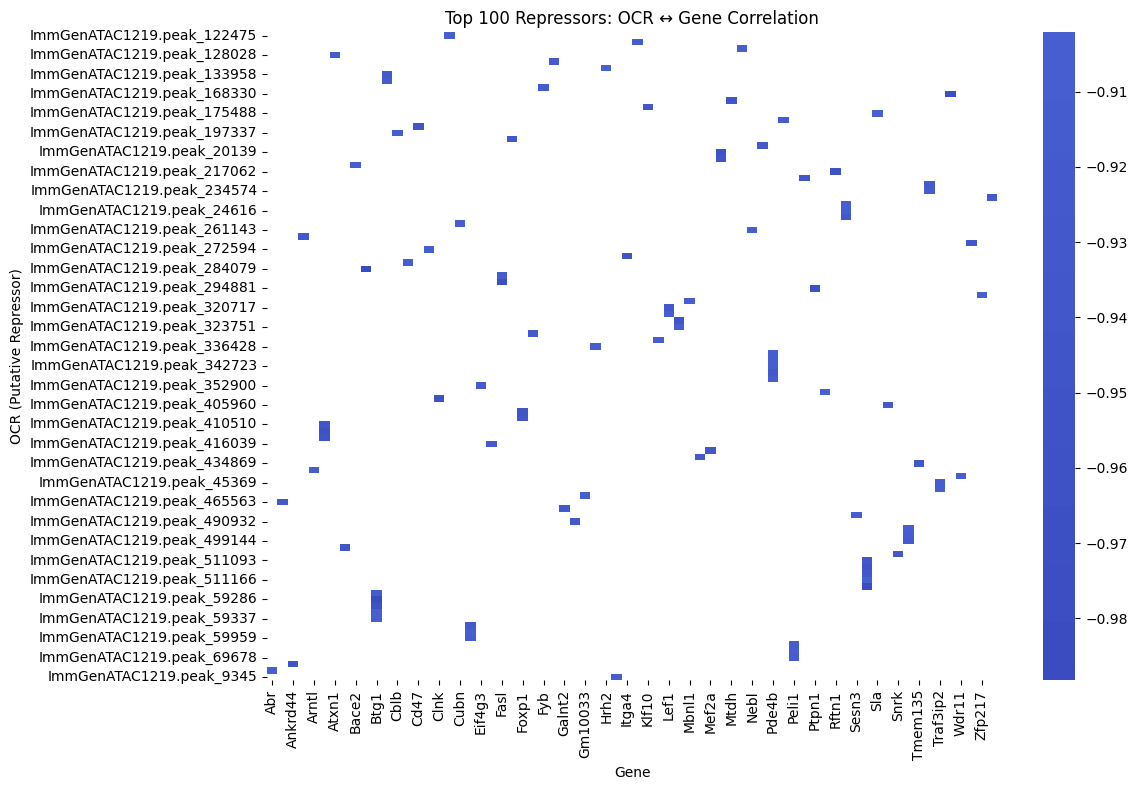

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

top_repr_assoc = repr_assoc_df.sort_values("correlation").head(100)

pivot_repr = top_repr_assoc.pivot(index="ocr_id", columns="gene", values="correlation")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_repr, cmap="coolwarm", center=0)
plt.title("Top 100 Repressors: OCR ↔ Gene Correlation")
plt.xlabel("Gene")
plt.ylabel("OCR (Putative Repressor)")
plt.tight_layout()
plt.savefig("Repressor_Gene_Correlation.png", dpi=300)
plt.show()


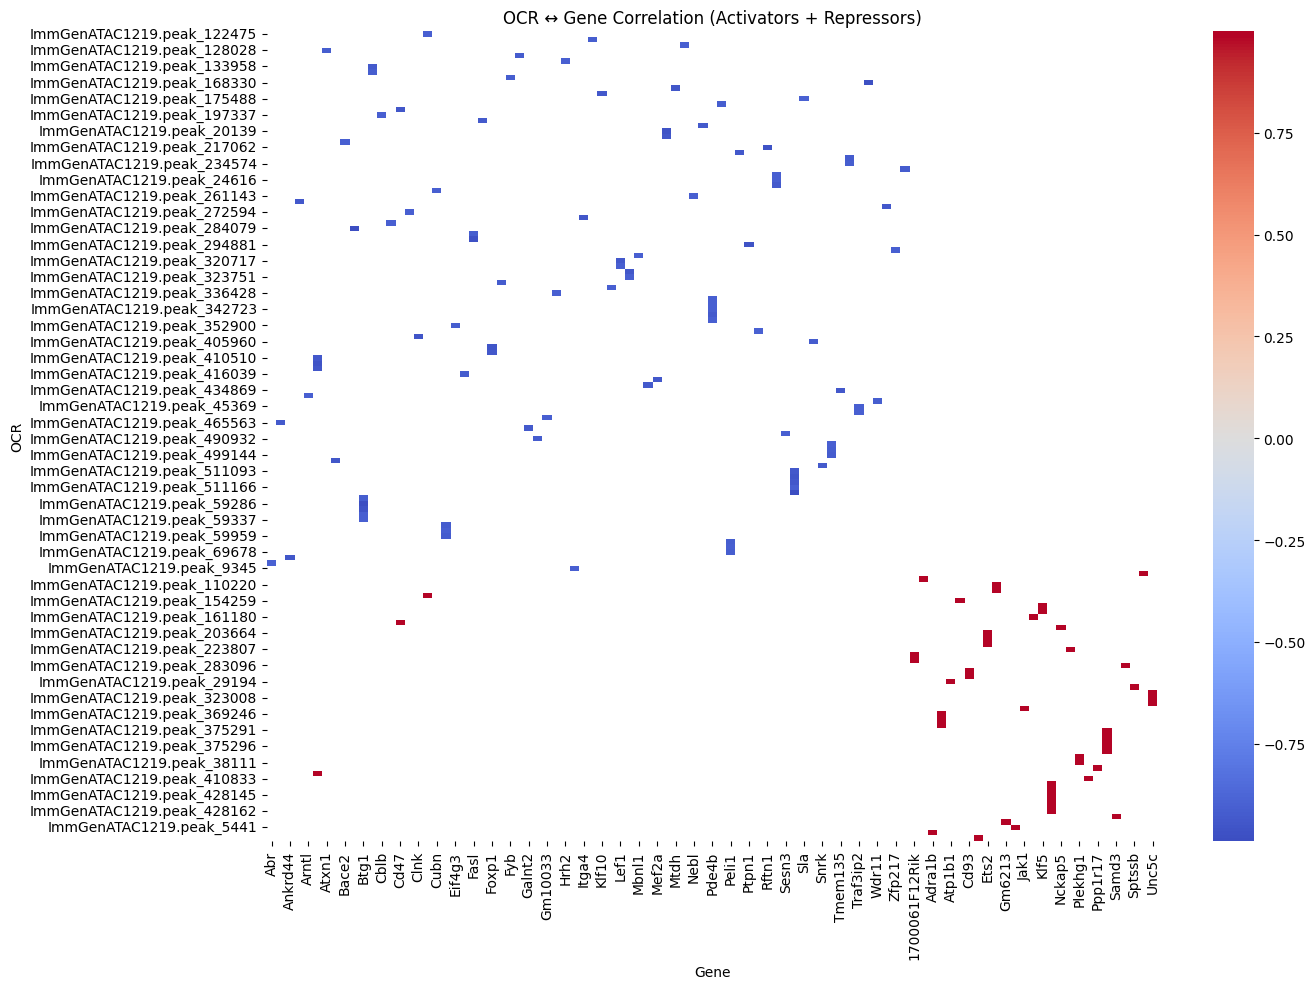

In [46]:
# Concatenar por filas (OCRs en eje Y)
combined_pivot = pd.concat([pivot_repr, pivot])

plt.figure(figsize=(14, 10))
sns.heatmap(combined_pivot, cmap="coolwarm", center=0)
plt.title("OCR ↔ Gene Correlation (Activators + Repressors)")
plt.xlabel("Gene")
plt.ylabel("OCR")
plt.tight_layout()
plt.savefig("Combined_OCR_Gene_Correlation.png", dpi=300)
plt.show()